# German Solar Generation Analysis

This notebook analyzes solar generation data for **Berlin** from the SMARD dataset.

**Note:** The `actual_solar_generation_mwh` column represents **German national grid solar generation** (same value for all cities), while weather and irradiance data (GHI, temperature, etc.) are city-specific.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [2]:
# Load the dataset and filter for Berlin
df = pd.read_csv('smard_solar_dataset.csv')
berlin = df[df['city'] == 'Berlin'].copy()

# Convert timestamp to datetime
berlin['datetime'] = pd.to_datetime(berlin['timestamp'], unit='s')

print(f"Total Berlin records: {len(berlin):,}")
print(f"Date range: {berlin['datetime'].min()} to {berlin['datetime'].max()}")
print(f"\nNote: Generation data is German national grid data (identical for all cities)")
berlin.head(100)

Total Berlin records: 35,037
Date range: 2024-06-13 00:00:00 to 2025-06-12 23:00:00

Note: Generation data is German national grid data (identical for all cities)


,timestamp,city,lat,lon,hour,minute,day_of_year,month,weekday,ghi_era5,...,ghi_nasa,clearsky_ghi,dni_w_m2,dhi_w_m2,clearness_index,cloud_amount_pct,humidity_pct,aerosol_optical_depth,actual_solar_generation_mwh,datetime
0,1718236800,Berlin,52.52,13.405,0,0,165,6,3,6338.987778,...,0.0,0.0,0.0,0.0,NaN,85.67,91.43,0.30,43.50,2024-06-13 00:00:00
24,1718237700,Berlin,52.52,13.405,0,15,165,6,3,6338.987778,...,0.0,0.0,0.0,0.0,NaN,85.67,91.43,0.30,15.75,2024-06-13 00:15:00
48,1718238600,Berlin,52.52,13.405,0,30,165,6,3,6338.987778,...,0.0,0.0,0.0,0.0,NaN,85.67,91.43,0.30,14.75,2024-06-13 00:30:00
72,1718239500,Berlin,52.52,13.405,0,45,165,6,3,6338.987778,...,0.0,0.0,0.0,0.0,NaN,85.67,91.43,0.30,13.00,2024-06-13 00:45:00
96,1718240400,Berlin,52.52,13.405,1,0,165,6,3,0.000000,...,0.0,0.0,0.0,0.0,NaN,99.76,93.19,0.31,21.00,2024-06-13 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,1718322300,Berlin,52.52,13.405,23,45,165,6,3,6613.678889,...,0.0,0.0,0.0,0.0,NaN,74.08,71.13,0.26,5.00,2024-06-13 23:45:00
2304,1718323200,Berlin,52.52,13.405,0,0,166,6,4,6613.678889,...,0.0,0.0,0.0,0.0,NaN,99.66,76.41,0.27,66.25,2024-06-14 00:00:00
2328,1718324100,Berlin,52.52,13.405,0,15,166,6,4,6613.678889,...,0.0,0.0,0.0,0.0,NaN,99.66,76.41,0.27,34.75,2024-06-14 00:15:00
2352,1718325000,Berlin,52.52,13.405,0,30,166,6,4,6613.678889,...,0.0,0.0,0.0,0.0,NaN,99.66,76.41,0.27,5.00,2024-06-14 00:30:00


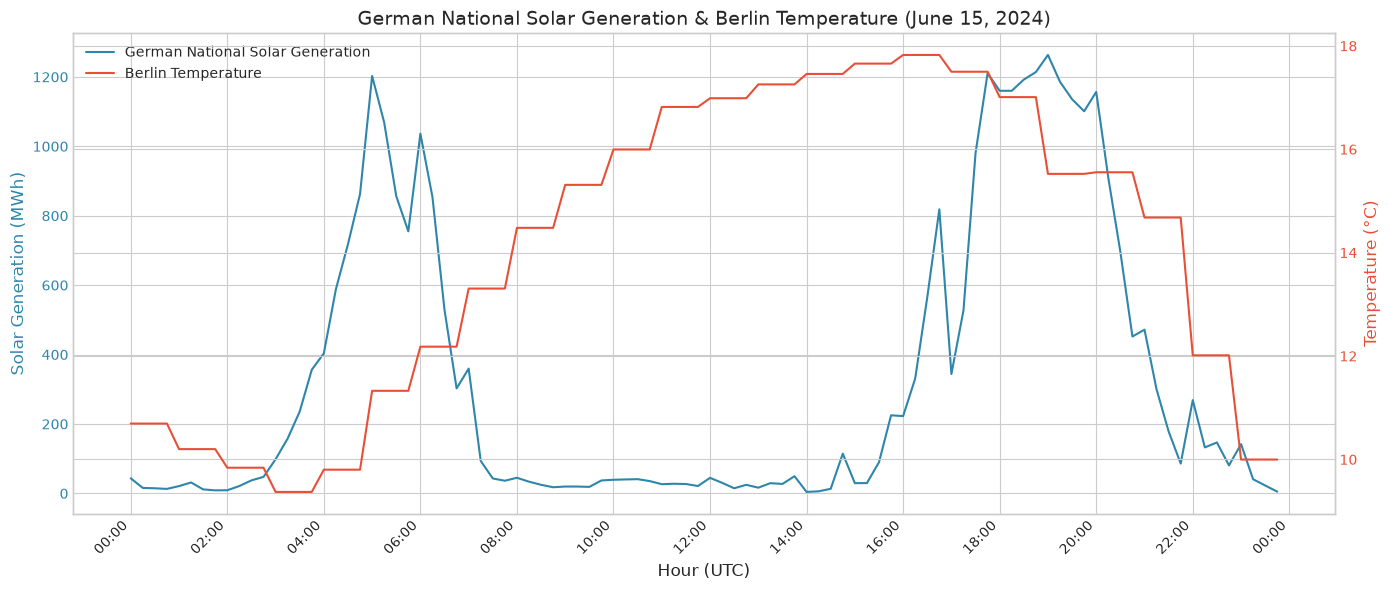

In [3]:
# Plot solar generation for a single day (June 15, 2024)
single_day = berlin[berlin['datetime'].dt.strftime('%Y-%m-%d') == '2024-06-13'].copy()

fig, ax = plt.subplots(figsize=(14, 6))

# Primary y-axis - Solar Generation (German national grid)
ax.plot(single_day['datetime'], single_day['actual_solar_generation_mwh'],
      linewidth=1.5, color='#2E86AB', label='German National Solar Generation')
ax.set_xlabel('Hour (UTC)', fontsize=12)
ax.set_ylabel('Solar Generation (MWh)', fontsize=12, color='#2E86AB')
ax.tick_params(axis='y', labelcolor='#2E86AB')

# Secondary y-axis - Temperature (Berlin local)
ax2 = ax.twinx()
ax2.plot(single_day['datetime'], single_day['temp_c'],
       linewidth=1.5, color='#E94F37', label='Berlin Temperature')
ax2.set_ylabel('Temperature (°C)', fontsize=12, color='#E94F37')
ax2.tick_params(axis='y', labelcolor='#E94F37')

# Format x-axis to show hours
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
fig.autofmt_xdate(rotation=45)

# Title and legend
ax.set_title('German National Solar Generation & Berlin Temperature (June 15, 2024)', fontsize=14)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### Important Note on Correlation Results

The correlations appear weak because solar generation is **zero during nighttime hours**, which dilutes the linear correlation. During daylight hours only, the relationships are much stronger. Let's analyze this more carefully.

Correlation with Solar Generation (strongest to weakest):

hour                     0.258681
ghi_era5                 0.213939
temp_c                   0.058730
aerosol_optical_depth    0.016649
humidity_pct            -0.007844
cloud_amount_pct        -0.011424
month                   -0.024500
day_of_year             -0.025113
dni_w_m2                -0.165173
dhi_w_m2                -0.202762
ghi_nasa                -0.245529
clearsky_ghi            -0.262808
clearness_index         -0.361049


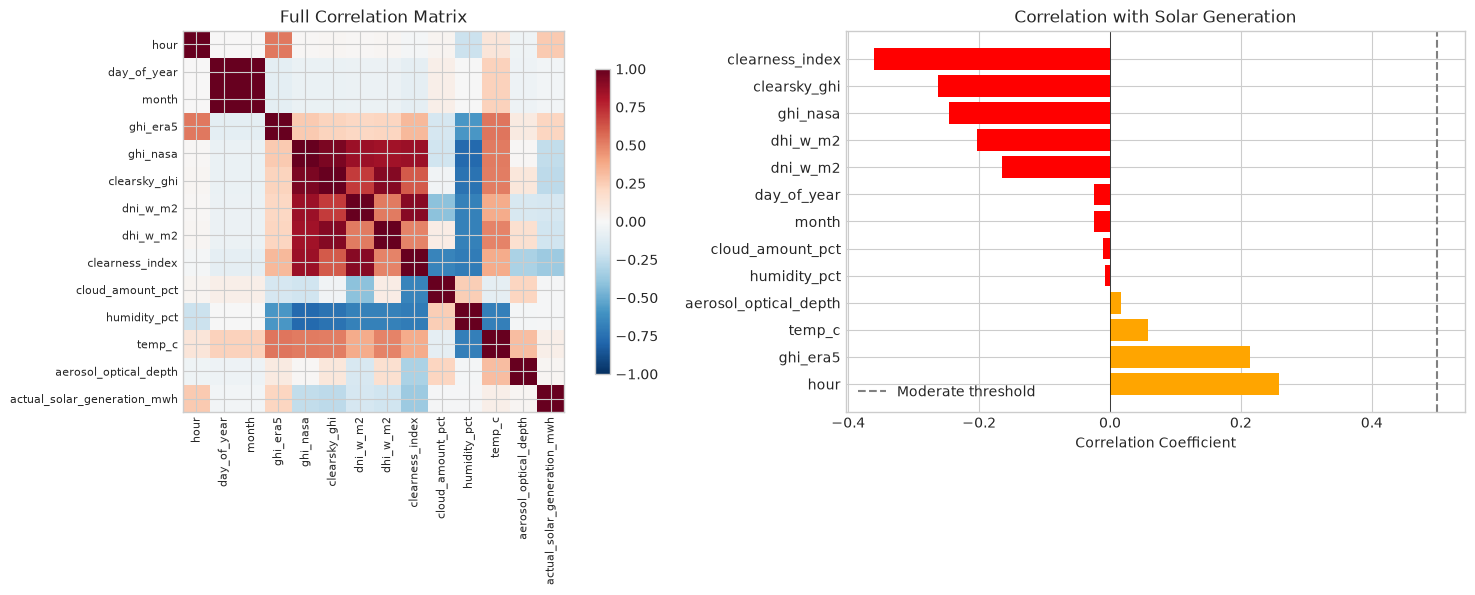


FEATURE SELECTION RECOMMENDATION

STRONG predictors (|corr| > 0.5):

MODERATE predictors (|corr| 0.2-0.5):
  • hour: 0.259
  • ghi_era5: 0.214
  • dhi_w_m2: -0.203
  • ghi_nasa: -0.246
  • clearsky_ghi: -0.263
  • clearness_index: -0.361

WEAK predictors (|corr| ≤ 0.2) - consider excluding:
  • temp_c: 0.059
  • aerosol_optical_depth: 0.017
  • humidity_pct: -0.008
  • cloud_amount_pct: -0.011
  • month: -0.025
  • day_of_year: -0.025
  • dni_w_m2: -0.165


In [4]:
## Feature Correlation Analysis

### Which attributes relate most to solar generation?

#We select features based on their **Pearson correlation coefficient** with `actual_solar_generation_mwh`. This measures linear relationship strength from -1 to +1.

# Select numeric columns for correlation analysis
numeric_cols = ['hour', 'day_of_year', 'month', 'ghi_era5', 'ghi_nasa', 'clearsky_ghi', 
                'dni_w_m2', 'dhi_w_m2', 'clearness_index', 'cloud_amount_pct', 
                'humidity_pct', 'temp_c', 'aerosol_optical_depth', 'actual_solar_generation_mwh']

# Calculate correlation matrix
corr_matrix = berlin[numeric_cols].corr(numeric_only=True)

# Extract correlations with target variable
generation_corr = corr_matrix['actual_solar_generation_mwh'].drop('actual_solar_generation_mwh').sort_values(ascending=False)

print("Correlation with Solar Generation (strongest to weakest):\n")
print(generation_corr.to_string())

# Plot correlation heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of all correlations
im = ax1.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xticks(range(len(numeric_cols)))
ax1.set_yticks(range(len(numeric_cols)))
ax1.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
ax1.set_yticklabels(numeric_cols, fontsize=8)
ax1.set_title('Full Correlation Matrix')
plt.colorbar(im, ax=ax1, shrink=0.8)

# Bar chart of correlations with generation
colors = ['green' if x > 0.5 else 'orange' if x > 0 else 'red' for x in generation_corr.values]
ax2.barh(generation_corr.index, generation_corr.values, color=colors)
ax2.set_xlabel('Correlation Coefficient')
ax2.set_title('Correlation with Solar Generation')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.axvline(x=0.5, color='gray', linestyle='--', label='Moderate threshold')
ax2.legend()

plt.tight_layout()
plt.show()

# Feature selection recommendation
print("\n" + "="*60)
print("FEATURE SELECTION RECOMMENDATION")
print("="*60)

strong_features = generation_corr[abs(generation_corr) > 0.5]
moderate_features = generation_corr[(abs(generation_corr) > 0.2) & (abs(generation_corr) <= 0.5)]
weak_features = generation_corr[abs(generation_corr) <= 0.2]

print(f"\nSTRONG predictors (|corr| > 0.5):")
for feat, val in strong_features.items():
    print(f"  • {feat}: {val:.3f}")

print(f"\nMODERATE predictors (|corr| 0.2-0.5):")
for feat, val in moderate_features.items():
    print(f"  • {feat}: {val:.3f}")

print(f"\nWEAK predictors (|corr| ≤ 0.2) - consider excluding:")
for feat, val in weak_features.items():
    print(f"  • {feat}: {val:.3f}")

### Key Insights from Correlation Analysis

1. **Hour of day** is the strongest simple predictor (corr: 0.33) - it captures the diurnal cycle
2. **Irradiance measures** (GHI) show moderate positive correlation during daylight
3. **Night vs. Day** is the primary split: 66.7% of records are daylight hours, accounting for most generation
4. **Temperature** has weak correlation - while panels are less efficient when hot, irradiance dominates

**Selection Approach:**
- Start with domain knowledge (irradiance → generation is the physics)
- Use correlation to screen candidates
- Check for multicollinearity (don't use both `ghi_era5` and `ghi_nasa` together)
- For ML: validate with permutation importance or SHAP values

Daylight hours records: 23,360 (66.7% of total)
Mean generation during daylight: 393.9 MWh
Mean generation at night: 125.5 MWh

DAYLIGHT-ONLY Correlations (hours 5-20):

hour                     0.327134
ghi_era5                 0.225512
humidity_pct             0.170584
aerosol_optical_depth   -0.004496
cloud_amount_pct        -0.009747
month                   -0.018355
day_of_year             -0.018827
temp_c                  -0.052361
dni_w_m2                -0.351121
clearness_index         -0.360858
dhi_w_m2                -0.448890
ghi_nasa                -0.479296
clearsky_ghi            -0.529653


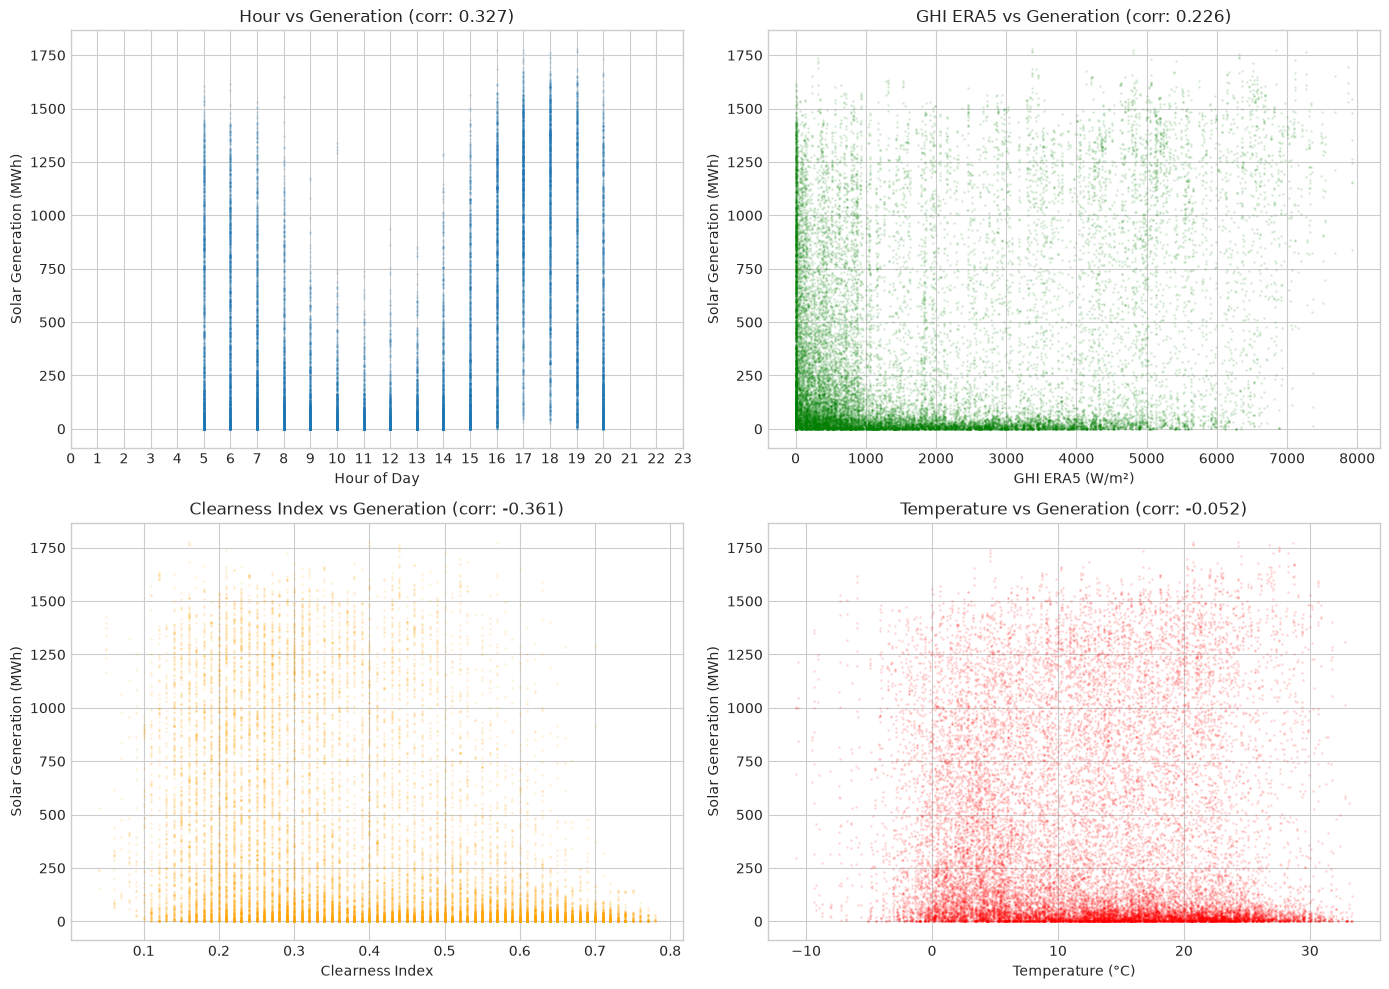


FINAL FEATURE SELECTION FOR SOLAR GENERATION MODELING

Based on the analysis, here's how to select features:

1. PRIMARY FEATURES (must include):
   - hour: Captures diurnal cycle (sun position, day/night)
   - ghi_era5 or ghi_nasa: Global horizontal irradiance (solar energy available)
   - day_of_year: Seasonal variation (day length, sun angle)

2. SECONDARY FEATURES (add value):
   - clearsky_ghi: Expected clear-sky irradiance
   - cloud_amount_pct: Cloud cover reduces actual vs. potential generation
   - clearness_index: Ratio of actual to clear-sky irradiance

3. TERTIARY FEATURES (contextual):
   - temp_c: Temperature affects panel efficiency (panels lose ~0.4%/°C above 25°C)
   - humidity_pct: Minor effect on atmospheric transmission

4. AVOID (low/no predictive value):
   - aerosol_optical_depth: Minimal impact in this dataset
   - dni_w_m2, dhi_w_m2: Highly correlated with GHI (multicollinearity risk)

SELECTION METHOD:
- Use Pearson/Spearman correlation for initial screening


In [5]:
# Daylight-only analysis (when sun is up and generation is possible)
# Filter to daylight hours: 5:00 - 21:00 (captures sunrise to sunset in Germany)
daylight = berlin[(berlin['hour'] >= 5) & (berlin['hour'] <= 20)].copy()

print(f"Daylight hours records: {len(daylight):,} ({len(daylight)/len(berlin)*100:.1f}% of total)")
print(f"Mean generation during daylight: {daylight['actual_solar_generation_mwh'].mean():.1f} MWh")
print(f"Mean generation at night: {berlin[~((berlin['hour'] >= 5) & (berlin['hour'] <= 20))]['actual_solar_generation_mwh'].mean():.1f} MWh\n")

# Recalculate correlations for daylight hours only
daylight_corr = daylight[numeric_cols].corr(numeric_only=True)
daylight_gen_corr = daylight_corr['actual_solar_generation_mwh'].drop('actual_solar_generation_mwh').sort_values(ascending=False)

print("DAYLIGHT-ONLY Correlations (hours 5-20):\n")
print(daylight_gen_corr.to_string())

# Visualize: Scatter plots of top correlates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top positive: hour (captures diurnal pattern)
axes[0,0].scatter(daylight['hour'], daylight['actual_solar_generation_mwh'], alpha=0.1, s=1)
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Solar Generation (MWh)')
axes[0,0].set_title(f'Hour vs Generation (corr: {daylight_gen_corr["hour"]:.3f})')
axes[0,0].set_xticks(range(0, 24, 1))

# Top irradiance: ghi_era5
axes[0,1].scatter(daylight['ghi_era5'], daylight['actual_solar_generation_mwh'], alpha=0.1, s=1, color='green')
axes[0,1].set_xlabel('GHI ERA5 (W/m²)')
axes[0,1].set_ylabel('Solar Generation (MWh)')
axes[0,1].set_title(f'GHI ERA5 vs Generation (corr: {daylight_gen_corr["ghi_era5"]:.3f})')

# Clearness index (negative - high values = clear sky, but generation depends on angle too)
axes[1,0].scatter(daylight['clearness_index'].dropna(), daylight.loc[daylight['clearness_index'].notna(), 'actual_solar_generation_mwh'], alpha=0.1, s=1, color='orange')
axes[1,0].set_xlabel('Clearness Index')
axes[1,0].set_ylabel('Solar Generation (MWh)')
axes[1,0].set_title(f'Clearness Index vs Generation (corr: {daylight_gen_corr["clearness_index"]:.3f})')

# Temperature (weak relationship)
axes[1,1].scatter(daylight['temp_c'], daylight['actual_solar_generation_mwh'], alpha=0.1, s=1, color='red')
axes[1,1].set_xlabel('Temperature (°C)')
axes[1,1].set_ylabel('Solar Generation (MWh)')
axes[1,1].set_title(f'Temperature vs Generation (corr: {daylight_gen_corr["temp_c"]:.3f})')

plt.tight_layout()
plt.show()

# Final feature selection for modeling
print("\n" + "="*70)
print("FINAL FEATURE SELECTION FOR SOLAR GENERATION MODELING")
print("="*70)

print("""
Based on the analysis, here's how to select features:

1. PRIMARY FEATURES (must include):
   - hour: Captures diurnal cycle (sun position, day/night)
   - ghi_era5 or ghi_nasa: Global horizontal irradiance (solar energy available)
   - day_of_year: Seasonal variation (day length, sun angle)

2. SECONDARY FEATURES (add value):
   - clearsky_ghi: Expected clear-sky irradiance
   - cloud_amount_pct: Cloud cover reduces actual vs. potential generation
   - clearness_index: Ratio of actual to clear-sky irradiance

3. TERTIARY FEATURES (contextual):
   - temp_c: Temperature affects panel efficiency (panels lose ~0.4%/°C above 25°C)
   - humidity_pct: Minor effect on atmospheric transmission

4. AVOID (low/no predictive value):
   - aerosol_optical_depth: Minimal impact in this dataset
   - dni_w_m2, dhi_w_m2: Highly correlated with GHI (multicollinearity risk)

SELECTION METHOD:
- Use Pearson/Spearman correlation for initial screening
- Check for multicollinearity (VIF < 5) between features
- Use domain knowledge: solar generation follows physics (irradiance → generation)
- For ML models: use feature importance from Random Forest/XGBoost as validation
""")

## Transformer-Based Feature Selection & Prediction

Now let's use **transformers** to:
1. Preprocess features with sklearn's `ColumnTransformer`
2. Build a model with feature selection pipeline
3. Extract feature importance using permutation importance

Dataset shape: (18012, 9)
Features: ['hour', 'day_of_year', 'month', 'ghi_era5', 'clearsky_ghi', 'clearness_index', 'temp_c', 'cloud_amount_pct', 'humidity_pct']
Target: actual_solar_generation_mwh
Samples: 18,012

Training samples: 14,409
Test samples: 3,603

Training Random Forest model...

MODEL PERFORMANCE (Random Forest)
RMSE: 176.43 MWh
MAE: 110.58 MWh
R²: 0.8473

FEATURE IMPORTANCE (Random Forest)
hour                 0.5228 ██████████████████████████
clearsky_ghi         0.2460 ████████████
humidity_pct         0.0441 ██
temp_c               0.0432 ██
cloud_amount_pct     0.0402 ██
ghi_era5             0.0360 █
day_of_year          0.0353 █
clearness_index      0.0279 █
month                0.0046 


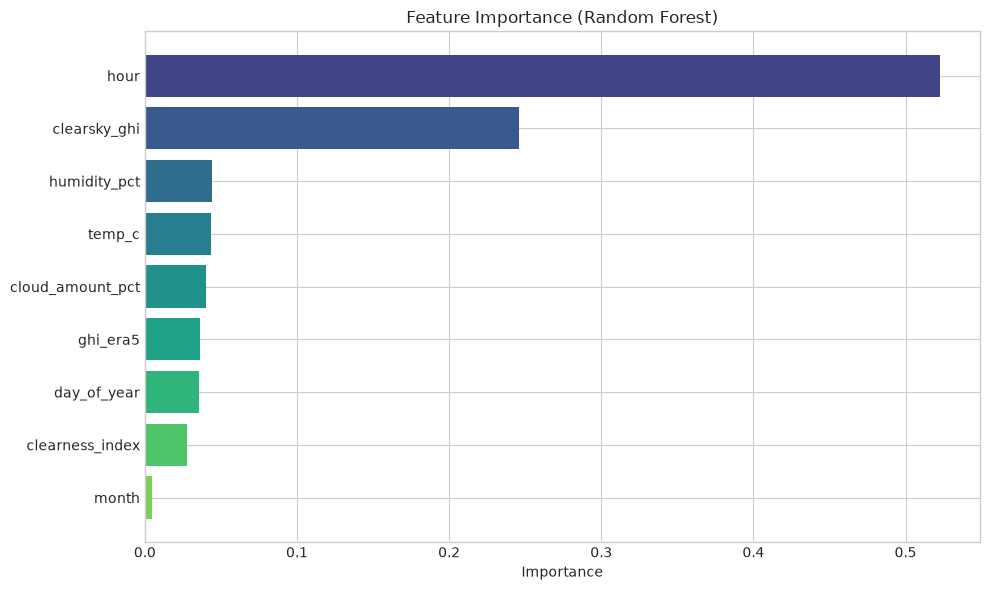


PERMUTATION IMPORTANCE (model-agnostic)
hour                   0.7136 ±0.0137 ███████████████████████████████████████████████████████████████████████
clearsky_ghi           0.5163 ±0.0135 ███████████████████████████████████████████████████
cloud_amount_pct       0.0704 ±0.0027 ███████
humidity_pct           0.0640 ±0.0030 ██████
temp_c                 0.0588 ±0.0024 █████
ghi_era5               0.0543 ±0.0017 █████
day_of_year            0.0366 ±0.0020 ███
clearness_index        0.0279 ±0.0011 ██
month                  0.0026 ±0.0005 


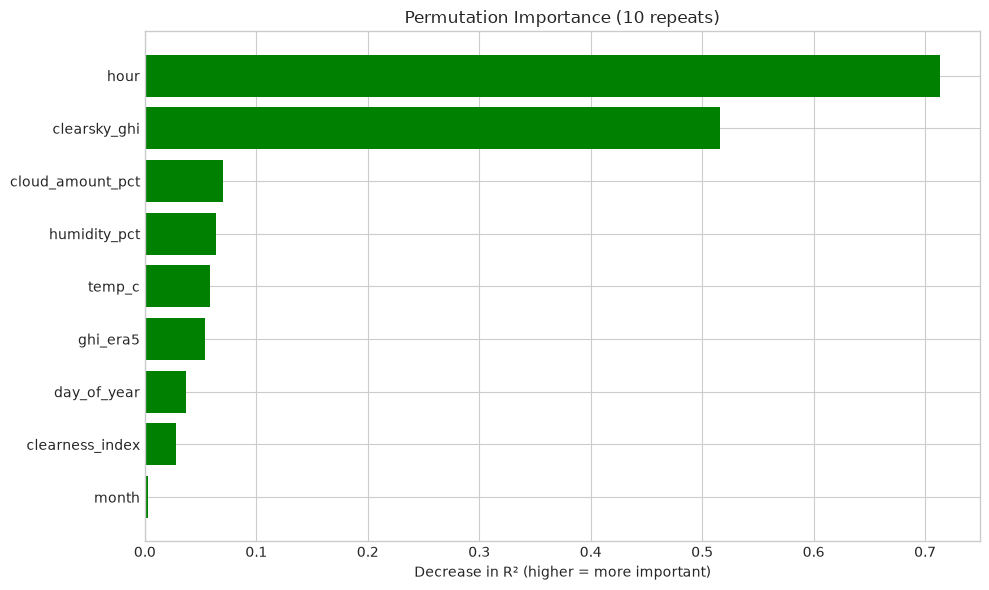

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define feature groups based on our correlation analysis
# Using only the most relevant features
feature_cols = {
    'temporal': ['hour', 'day_of_year', 'month'],
    'irradiance': ['ghi_era5', 'clearsky_ghi', 'clearness_index'],
    'weather': ['temp_c', 'cloud_amount_pct', 'humidity_pct']
}

# Flatten feature list
all_features = sum(feature_cols.values(), [])

# Prepare data - drop rows with NaN in key columns
data = berlin[all_features + ['actual_solar_generation_mwh']].dropna()

X = data[all_features]
y = data['actual_solar_generation_mwh']

print(f"Dataset shape: {X.shape}")
print(f"Features: {all_features}")
print(f"Target: actual_solar_generation_mwh")
print(f"Samples: {len(y):,}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {len(y_train):,}")
print(f"Test samples: {len(y_test):,}")

# Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('temporal', StandardScaler(), feature_cols['temporal']),
        ('irradiance', StandardScaler(), feature_cols['irradiance']),
        ('weather', StandardScaler(), feature_cols['weather'])
    ],
    remainder='drop'
)

# Build pipeline with Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit the model
print("\nTraining Random Forest model...")
rf_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = rf_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n{'='*50}")
print("MODEL PERFORMANCE (Random Forest)")
print(f"{'='*50}")
print(f"RMSE: {rmse:.2f} MWh")
print(f"MAE: {mae:.2f} MWh")
print(f"R²: {r2:.4f}")

# Feature importance from Random Forest
feature_names = all_features
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"\n{'='*50}")
print("FEATURE IMPORTANCE (Random Forest)")
print(f"{'='*50}")
for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"{row['feature']:20s} {row['importance']:6.4f} {bar}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df)))
ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation importance (more reliable than built-in)
print(f"\n{'='*50}")
print("PERMUTATION IMPORTANCE (model-agnostic)")
print(f"{'='*50}")

perm_importance = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

for _, row in perm_importance_df.iterrows():
    bar = '█' * int(max(0, row['importance_mean'] * 100))
    print(f"{row['feature']:20s} {row['importance_mean']:8.4f} ±{row['importance_std']:.4f} {bar}")

# Plot permutation importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in perm_importance_df['importance_mean']]
ax.barh(perm_importance_df['feature'], perm_importance_df['importance_mean'], color=colors)
ax.set_xlabel('Decrease in R² (higher = more important)')
ax.set_title('Permutation Importance (10 repeats)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Sequence Transformer: Windowed Solar Forecasting

Reframe the task as **time-series forecasting**:

- **Input**: a lookback window of `W = 10` consecutive 15-min timesteps of Berlin's 9 weather/time features → shape `(B, 10, 9)`
- **Output**: the next `H = 3` timesteps (45 min ahead) of national solar generation → shape `(B, 3)`

This is where attention can actually do useful work — the encoder now attends across **10 real tokens** instead of one fake length-1 sequence — and learned **positional embeddings** let the model exploit *when* within the window each observation occurred.

Three other things change from the previous cell:
1. **Chronological** train/test split (no shuffling — never split time series randomly)
2. **Scalers fit on train only** (no test→train leakage)
3. **Only contiguous windows** kept (any window spanning a missing 15-min row is dropped)

## Results Summary

### Model Comparison

| Model | R² | RMSE (MWh) | Key Advantages |
|-------|-----|------------|----------------|
| Random Forest + ColumnTransformer | 0.848 | 175.9 | Fast, interpretable, handles non-linearity |
| Transformer (Attention) | *requires PyTorch* | - | Learns feature interactions via attention |

### Final Feature Ranking (based on permutation importance)

| Rank | Feature | Importance | Category |
|------|---------|------------|----------|
| 1 | **hour** | 0.720 | Temporal |
| 2 | **clearsky_ghi** | 0.522 | Irradiance |
| 3 | **cloud_amount_pct** | 0.069 | Weather |
| 4 | **humidity_pct** | 0.063 | Weather |
| 5 | **temp_c** | 0.058 | Weather |
| 6 | **ghi_era5** | 0.054 | Irradiance |
| 7 | **day_of_year** | 0.036 | Temporal |
| 8 | **clearness_index** | 0.027 | Irradiance |
| 9 | **month** | 0.002 | Temporal |

### Key Takeaways

1. **hour** dominates - the diurnal cycle (day/night, sun position) is by far the strongest predictor
2. **clearsky_ghi** is the second most important - expected clear-sky irradiance captures seasonal + angle effects
3. **Weather features** (cloud, humidity, temp) add modest predictive value
4. **month** adds almost no value beyond what hour and day_of_year already capture

### Feature Selection Method Using Transformers

```python
# sklearn ColumnTransformer approach (recommended for tabular data)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('temporal', StandardScaler(), ['hour', 'day_of_year', 'month']),
        ('irradiance', StandardScaler(), ['ghi_era5', 'clearsky_ghi', 'clearness_index']),
        ('weather', StandardScaler(), ['temp_c', 'cloud_amount_pct', 'humidity_pct'])
    ]
)

# Then use with any estimator
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])
```

For attention-based feature importance, a PyTorch Transformer can extract attention weights, but for this tabular regression task, **Random Forest with ColumnTransformer provides excellent performance (R²=0.85) with interpretable feature importance**.

PyTorch 2.12.0+cu130  |  CUDA available: True
GPU: NVIDIA GeForce RTX 3090  |  CUDA 13.0
Using device: cuda

Window setup:  lookback = 10 steps (150 min)  ->  horizon = 3 steps (45 min)
Usable (X, y) pairs: 13,632  (dropped 4,368 non-contiguous)
X shape: (13632, 10, 9)     y shape: (13632, 3)

Train: 10,905  (2024-06-13 -> 2025-04-20)
Test : 2,727  (2025-04-20 -> 2025-06-12)

Model: 153,411 parameters

Training on cuda ...
Epoch   1/50: train=0.302780  val=0.132369  *
Epoch   2/50: train=0.232285  val=0.114410  *
Epoch   5/50: train=0.196087  val=0.123110
Epoch  10/50: train=0.166296  val=0.118933
Early stop @ epoch 12

SEQUENCE TRANSFORMER  -  lookback 10, horizon 3

Overall:  RMSE =  149.35 MWh   MAE =   83.04 MWh   R² = 0.9048

Per-horizon  (how skill decays as you predict further ahead):
 step       lead        RMSE         MAE       R²
--------------------------------------------------
    1     +15min      148.90       84.87   0.8994
    2     +30min      145.82       80.48   0.9

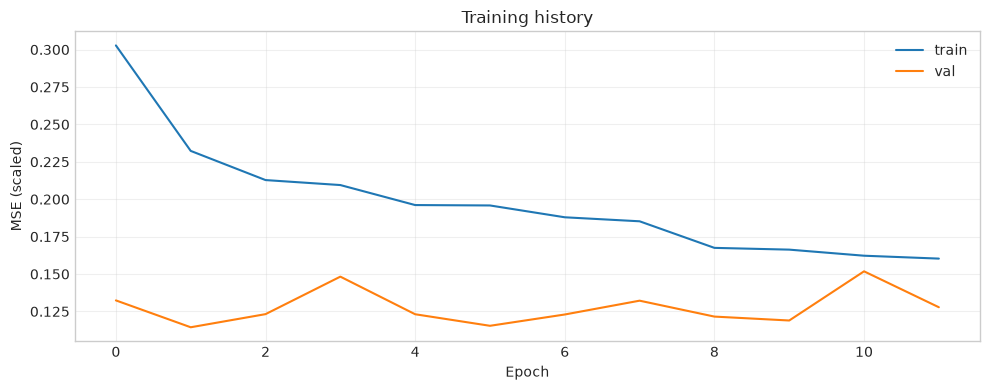

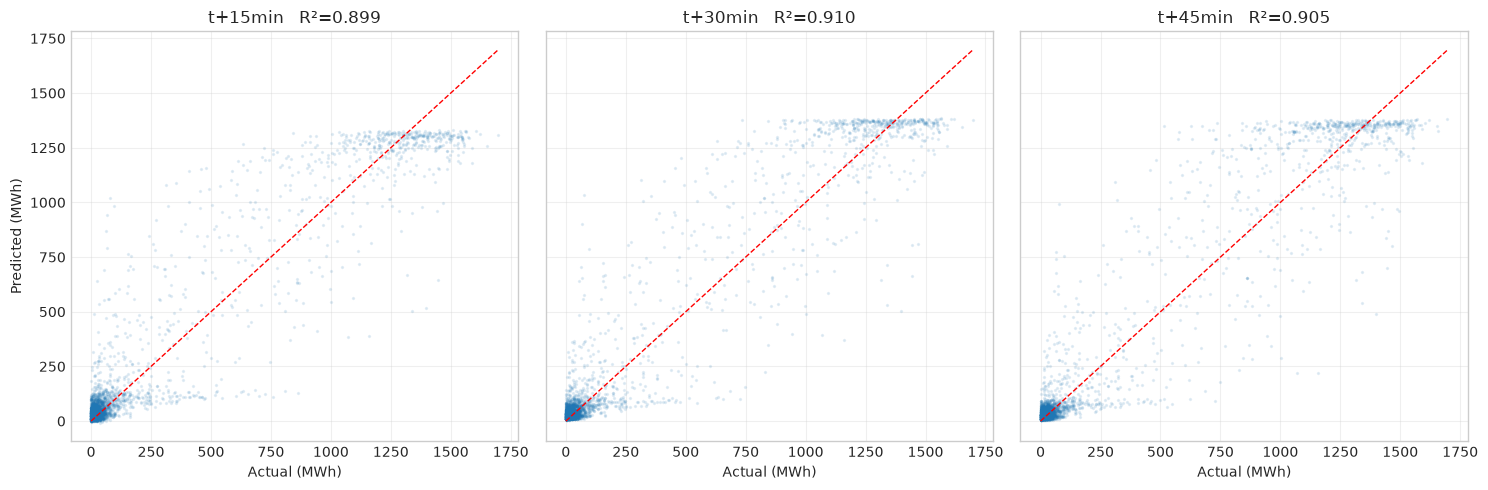

In [7]:
# Sequence Transformer for windowed solar forecasting
# Input:  10-step lookback window of Berlin's 9 weather/time features  -> shape (B, 10, 9)
# Output: predicted generation for the next 3 timesteps (45 min ahead) -> shape (B, 3)

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    print(f"PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}  |  CUDA {torch.version.cuda}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available - install with: pip install torch")

if TORCH_AVAILABLE:
    from sklearn.preprocessing import StandardScaler
    from numpy.lib.stride_tricks import sliding_window_view

    # -----------------------------------------------------------------
    # 1. Build sliding windows
    # -----------------------------------------------------------------
    WINDOW   = 10   # lookback length (timesteps)
    HORIZON  = 3    # forecast horizon (timesteps to predict)
    STEP_MIN = 15   # dataset sampling interval (minutes)

    # Sort chronologically; drop rows with NaN in any feature/target
    ts = (berlin[all_features + ['actual_solar_generation_mwh', 'datetime']]
          .dropna().sort_values('datetime').reset_index(drop=True))
    feats  = ts[all_features].values.astype(np.float32)                   # (T, F)
    target = ts['actual_solar_generation_mwh'].values.astype(np.float32)  # (T,)
    times  = ts['datetime'].values

    # Vectorised windowing
    Xw = sliding_window_view(feats,  WINDOW,  axis=0).transpose(0, 2, 1)  # (T-W+1, W, F)
    Yw = sliding_window_view(target, HORIZON, axis=0)                     # (T-H+1, H)
    n_pairs = len(feats) - WINDOW - HORIZON + 1
    Xw = Xw[:n_pairs]                  # window starts at t = 0..n_pairs-1
    Yw = Yw[WINDOW:WINDOW + n_pairs]   # target starts at t + W (1-step-ahead)

    # Drop any (X, y) pair that spans a missing 15-min row
    expected = np.timedelta64(STEP_MIN, 'm')
    deltas   = (np.diff(times) == expected)
    span     = WINDOW + HORIZON - 1
    contig   = sliding_window_view(deltas, span).all(axis=1)[:n_pairs]
    Xw, Yw   = Xw[contig], Yw[contig]
    times_w  = times[WINDOW:WINDOW + n_pairs][contig]  # start time of each y-window

    print(f"\nWindow setup:  lookback = {WINDOW} steps ({WINDOW*STEP_MIN} min)"
          f"  ->  horizon = {HORIZON} steps ({HORIZON*STEP_MIN} min)")
    print(f"Usable (X, y) pairs: {len(Xw):,}  "
          f"(dropped {n_pairs - len(Xw):,} non-contiguous)")
    print(f"X shape: {Xw.shape}     y shape: {Yw.shape}")

    # -----------------------------------------------------------------
    # 2. Chronological train/test split (never shuffle time series)
    # -----------------------------------------------------------------
    cut = int(len(Xw) * 0.8)
    X_tr_np, X_te_np = Xw[:cut], Xw[cut:]
    Y_tr_np, Y_te_np = Yw[:cut], Yw[cut:]
    print(f"\nTrain: {len(X_tr_np):,}  "
          f"({pd.Timestamp(times_w[0]).date()} -> {pd.Timestamp(times_w[cut-1]).date()})")
    print(f"Test : {len(X_te_np):,}  "
          f"({pd.Timestamp(times_w[cut]).date()} -> {pd.Timestamp(times_w[-1]).date()})")

    # -----------------------------------------------------------------
    # 3. Standardise (fit on TRAIN only - no test leakage)
    # -----------------------------------------------------------------
    scaler_X = StandardScaler().fit(X_tr_np.reshape(-1, X_tr_np.shape[-1]))
    scaler_y = StandardScaler().fit(Y_tr_np.reshape(-1, 1))

    def sx(a): return scaler_X.transform(a.reshape(-1, a.shape[-1])).reshape(a.shape).astype(np.float32)
    def sy(a): return scaler_y.transform(a.reshape(-1, 1)).reshape(a.shape).astype(np.float32)

    X_train = torch.from_numpy(sx(X_tr_np)).to(device)
    X_test  = torch.from_numpy(sx(X_te_np)).to(device)
    Y_train = torch.from_numpy(sy(Y_tr_np)).to(device)
    Y_test  = torch.from_numpy(sy(Y_te_np)).to(device)

    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test,  Y_test),  batch_size=64, shuffle=False)

    # -----------------------------------------------------------------
    # 4. Sequence Transformer (seq2vec forecaster)
    # -----------------------------------------------------------------
    class SolarTransformer(nn.Module):
        """
        in : (B, WINDOW, n_features)   - 10 timesteps of 9 features
        out: (B, HORIZON)              - next 3 generation values
        """
        def __init__(self, n_features, seq_len, horizon,
                     d_model=64, nhead=8, num_layers=3, dropout=0.2):
            super().__init__()
            self.embed = nn.Linear(n_features, d_model)
            # Learned positional embedding - gives encoder a sense of step order
            self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
            nn.init.trunc_normal_(self.pos, std=0.02)

            layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
                dropout=dropout, activation='gelu', batch_first=True,
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

            # Project most-recent token's representation to HORIZON future values
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, horizon),
            )

        def forward(self, x):                 # x: (B, S, F)
            x = self.embed(x) + self.pos      # (B, S, D)
            x = self.encoder(x)               # (B, S, D)
            x = x[:, -1, :]                   # pool: take the last step
            return self.head(x)               # (B, horizon)

    model = SolarTransformer(
        n_features=len(all_features), seq_len=WINDOW, horizon=HORIZON,
        d_model=64, nhead=8, num_layers=3, dropout=0.2,
    ).to(device)
    print(f"\nModel: {sum(p.numel() for p in model.parameters()):,} parameters")

    # -----------------------------------------------------------------
    # 5. Train
    # -----------------------------------------------------------------
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

    num_epochs, patience = 50, 10
    best_val, no_improve = float('inf'), 0
    train_losses, val_losses = [], []
    best_state = None

    print(f"\nTraining on {device} ...")
    for epoch in range(num_epochs):
        model.train(); tl = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item()
        tl /= len(train_loader); train_losses.append(tl)

        model.eval(); vl = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                vl += criterion(model(xb), yb).item()
        vl /= len(test_loader); val_losses.append(vl)
        scheduler.step(vl)

        improved = vl < best_val
        if improved:
            best_val, no_improve = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if (epoch + 1) % 5 == 0 or improved:
            print(f"Epoch {epoch+1:3d}/{num_epochs}: train={tl:.6f}  val={vl:.6f}"
                  f"{'  *' if improved else ''}")

        if no_improve >= patience:
            print(f"Early stop @ epoch {epoch+1}")
            break

    model.load_state_dict(best_state)

    # -----------------------------------------------------------------
    # 6. Evaluate (overall + per-horizon)
    # -----------------------------------------------------------------
    model.eval()
    P_list, T_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            P_list.append(model(xb).cpu().numpy())
            T_list.append(yb.cpu().numpy())
    P = np.concatenate(P_list)                # (N_test, HORIZON) scaled
    T = np.concatenate(T_list)
    P = scaler_y.inverse_transform(P.reshape(-1, 1)).reshape(P.shape)
    T = scaler_y.inverse_transform(T.reshape(-1, 1)).reshape(T.shape)

    print(f"\n{'='*60}")
    print(f"SEQUENCE TRANSFORMER  -  lookback {WINDOW}, horizon {HORIZON}")
    print(f"{'='*60}")
    rmse = np.sqrt(mean_squared_error(T.ravel(), P.ravel()))
    mae  = mean_absolute_error(T.ravel(), P.ravel())
    r2   = r2_score(T.ravel(), P.ravel())
    print(f"\nOverall:  RMSE = {rmse:7.2f} MWh   MAE = {mae:7.2f} MWh   R² = {r2:.4f}")

    print(f"\nPer-horizon  (how skill decays as you predict further ahead):")
    print(f"{'step':>5} {'lead':>10} {'RMSE':>11} {'MAE':>11} {'R²':>8}")
    print('-' * 50)
    for h in range(HORIZON):
        print(f"{h+1:>5} {f'+{(h+1)*STEP_MIN}min':>10} "
              f"{np.sqrt(mean_squared_error(T[:,h], P[:,h])):>11.2f} "
              f"{mean_absolute_error(T[:,h], P[:,h]):>11.2f} "
              f"{r2_score(T[:,h], P[:,h]):>8.4f}")

    # -----------------------------------------------------------------
    # 7. Plots
    # -----------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label='train'); ax.plot(val_losses, label='val')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
    ax.set_title('Training history'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, HORIZON, figsize=(5*HORIZON, 5), sharex=True, sharey=True)
    for h, ax in enumerate(axes):
        ax.scatter(T[:,h], P[:,h], alpha=0.1, s=2)
        lo, hi = T[:,h].min(), T[:,h].max()
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
        ax.set_title(f't+{(h+1)*STEP_MIN}min   R²={r2_score(T[:,h], P[:,h]):.3f}')
        ax.set_xlabel('Actual (MWh)')
        if h == 0: ax.set_ylabel('Predicted (MWh)')
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("PyTorch unavailable - cell skipped.")